In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from copula_mp import mp_density, mp_density_t_learner, mp_density_iv

## The effect of institutions on economic growth

In [8]:
# load data and partial out residuals
d = pd.read_csv("Data/AJR_Data.csv")

y_raw = d['GDP'].values
x_raw = d['Exprop'].values
z_raw = d['logMort'].values

# Create covariate matrix W (Intercept + Latitude)
ones = np.ones(len(d))
W = np.column_stack([ones, d['Latitude'].values])

# Construct the Residual Maker Matrix (M_W = I - W(W'W)⁻¹W')
# This "projects out" the covariates from the variables
I = np.eye(len(W))
W_inv_W = np.linalg.inv(W.T @ W)
M_W = I - W @ W_inv_W @ W.T

# Project out covariates to get the residuals
y = M_W @ y_raw
x = M_W @ x_raw
z = M_W @ z_raw

In [9]:
# define parameters
y_grid = np.linspace(y.min() - 0.5, y.max() + 0.5, 50)
T_fwd, B_post = 100, 100

# fit martingale posteriors and compute density estimates for S-Learner
res = mp_density_iv(y, x, z, [4, 8], y_grid, B_post, T_fwd)
res_4, res_8 = res['x_0'], res['x_1']


First-stage estimation:
  Estimated coefficients: [ 2.25600788e-15 -5.37174110e-01]
  Mean residual: 0.000000
  Std residual: 1.217952
Compiling...
Compilation time: 0.02s
Optimizing...
Optimization time: 0.143s
Fitting...
Fit time: 0.003s

Conditional density fit:
  Optimised rho: 0.4705147445201874
  Optimised rho_x: [0.9185218 0.9208853]
  Prequential log-likelihood: -1.1547985076904297
Predicting...
Prediction time: 0.189s
Predictive resampling...
Predictive resampling time: 0.76s


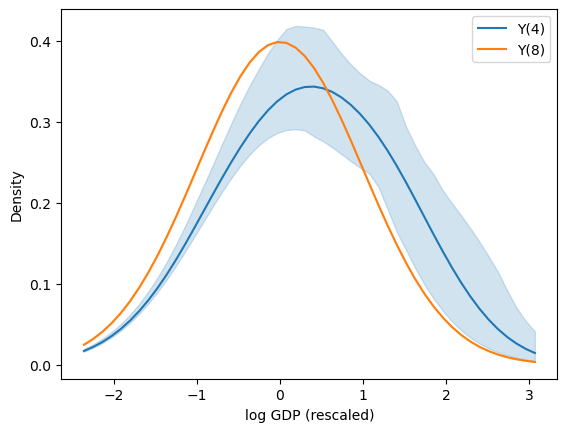

In [18]:

plt.plot(y_grid, res_4['mean'], label="Y(4)", color='tab:blue')
plt.fill_between(y_grid, res_4['low'], res_4['high'], color='tab:blue', alpha=0.2)

plt.plot(y_grid, res_8['mean'], label="Y(8)", color='tab:orange')
plt.fill_between(y_grid, res_8['low'], res_8['high'], color='tab:orange', alpha=0.2)

#plt.xscale('log')
plt.xlabel("log GDP (rescaled)")
plt.ylabel("Density") 
plt.legend()

plt.show()

In [17]:
res['x_1']

{'mean': array([0.02483465, 0.03204018, 0.04083283, 0.05140457, 0.06392511,
        0.07852693, 0.09528915, 0.11422087, 0.13524617, 0.15819116,
        0.18277486, 0.20860662, 0.235189  , 0.26192886, 0.2881556 ,
        0.3131467 , 0.33615974, 0.35646826, 0.3733992 , 0.3863697 ,
        0.39492053, 0.3987435 , 0.39769924, 0.39182568, 0.38133633,
        0.36660683, 0.34815297, 0.32660034, 0.30264956, 0.27703896,
        0.25050628, 0.22375536, 0.1974264 , 0.17207359, 0.14814945,
        0.12599781, 0.10585299, 0.08784559, 0.07201354, 0.05831565,
        0.04664803, 0.03686025, 0.02877136, 0.02218397, 0.01689643,
        0.01271242, 0.00944796, 0.00693625, 0.00503025, 0.00360355],
       dtype=float32),
 'low': array([0.02482869, 0.03203299, 0.04082421, 0.05139446, 0.0639134 ,
        0.07851356, 0.09527406, 0.11420397, 0.13522792, 0.15817173,
        0.18275452, 0.20858562, 0.23516774, 0.2619081 , 0.28813568,
        0.3131279 , 0.33614206, 0.35645244, 0.37338337, 0.3863553 ,
        0